### Decorators 

    In Python, decorators are flexible way to modify or extend behavior of functions or methods, without changing their actual code.
    
    A decorator is essentially a function that takes another function as an argument and returns a new function with enhanced functionality.
    
    Decorators are often used in scenarios such as logging, authentication and memorization, allowing us to add additional functionality to existing functions or methods in a clean, reusable way.

<center>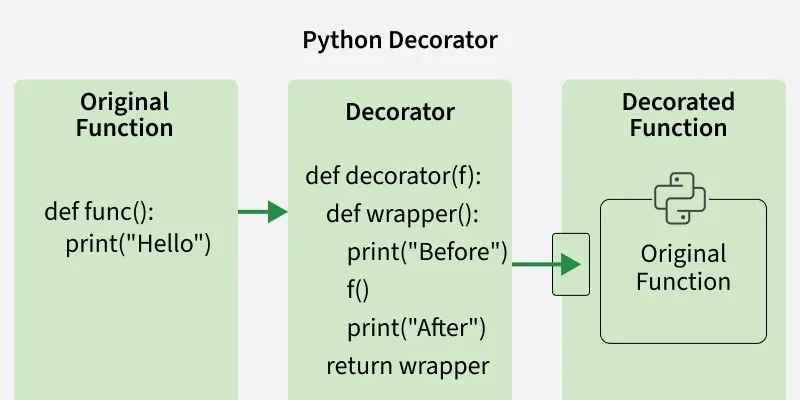</center>

`A Decorator in Python is a design pattern that allows you to add new functionality to an existing function without modifying its original code.`

In simple terms: A decorator wraps another function and extends its behavior. A decorator is a function that modifies another function without changing its code

In [9]:
"""
To understand why decorators were invented, we need to look at the problem developers had before decorators existed.
The core idea is about adding behavior to many functions without repeating code.
1. The Problem Before Decorators Imagine you want to log every function call."""


def add(a, b):
    print("Function started")
    result = a + b
    print("Function finished")
    return result


def multiply(a, b):
    print("Function started")
    result = a * b
    print("Function finished")
    return result


add(4,5)
multiply(4,5)

Function started
Function finished
Function started
Function finished


20

In [11]:
"""2. First Solution (Using Normal Functions)
Developers tried something like this."""

def logger(func):

    def wrapper(a, b):
        print("Function started")

        result = func(a, b)

        print("Function finished")

        return result

    return wrapper

def add(a, b):
    return a + b

add = logger(add)
print(add(2, 3))

# But the problem is syntax becomes ugly.

Function started
Function finished
5


In [14]:
"""3. Why Decorator Syntax Was Introduced
Instead of writing: add = logger(add)
Python introduced decorator syntax.
@logger
def add(a, b):
    return a + b
Python internally does: add = logger(add)"""

@logger
def add(a, b):
    return a + b
    
add(2,3)

Function started
Function finished


5

In [15]:
"""4. Core Logic Behind Decorators 🧠
1️⃣ Functions are Objects
In Python, functions behave like data."""
def greet():
    print("Hello")

print(type(greet))

<class 'function'>


In [5]:
# 2️⃣ Functions Can Be Passed to Other Functions
def greet():
    print("hello")

def execute(func):
    func()

execute(greet)
# Here greet is passed as argument.

hello


In [7]:
# 3️⃣ Functions Can Return Functions
def outer():

    def inner():
        print("inside")

    return inner

In [8]:
outer()

<function __main__.outer.<locals>.inner()>

In [2]:
# Normal function
def greet(name):
    print("Something extra")
    return f"Hello {name}"


greet('Raj Kumar')

Something extra


'Hello Raj Kumar'

In [47]:
def my_decorator(func):
    def wrapper(*args):
        print('Before Execution: ')
        result = func(*args)
        return result
        print('After Execution')
        return result
    return wrapper


@my_decorator
def say_hello(a, b):
    return (a + b)

say_hello(2, 3)

Before Execution: 


5

| Feature          | Normal Function | Decorator                 |
| ---------------- | --------------- | ------------------------- |
| Purpose          | Executes logic  | Modifies another function |
| Reusability      | Limited         | Highly reusable           |
| Code duplication | More            | Less                      |
| Control          | Inside function | Outside function          |
| Use case         | Simple tasks    | Cross-cutting logic       |


Scenario: Login System

You have many functions:
view_profile(),
update_profile(),
delete_account()

In [15]:
def hello():
    print('heelo')
    return hello


print(hello())

heelo
<function hello at 0x00000119C8845800>


In [10]:
# ❌ Without Decorator (Bad approach)
def view_profile():
    print("Checking login...")
    print("Showing profile")


def update_profile():
    print("Checking login...")
    print("Updating profile")

# Problem:code repetition 😓

In [16]:
# ✅ With Decorator (Best approach)

def login_required(func):
    def wrapper():
        print('checking loging in')
        func()
    return wrapper


#useit
@login_required
def view_profile():
    print("Showing profile")

@login_required
def update_profile():  #update_profile = login_required(update_profile)
    print("Updating profile")

view_profile()
update_profile()

# 👉 Normal function = Worker
# 👉 Decorator = Supervisor

checking loging in
Showing profile
checking loging in
Updating profile


Where decorators are used in real life

- Authentication (login_required)
- Logging (track function calls)
- Timing (measure execution time)
- Caching (store results)
- API frameworks (Flask, FastAPI use decorators heavily)

In [17]:
def decorator(func):
    def wrapper():
        print("Before calling the function.")
        func()
        print("After calling the function.")
    return wrapper


@decorator # Applying the decorator to a function
def greet():
    print("Hello, World!")
greet()

Before calling the function.
Hello, World!
After calling the function.


**Decorator with Parameters**

    Decorators often need to work with functions that have arguments.
    We use *args and **kwargs so our wrapper can accept any number of arguments.

In [7]:
def decorator_name(func):
    def wrapper(*args, **kwargs):
        print('Before Execution')
        result = func(*args, **kwargs)
        print('After Execution')
        return result
    return wrapper


@decorator_name
def add(a, b):
    print('value of %d & %d'%(a,b))
    return f'adding those two elements {a + b}'


add(b = 12, a = 15)

Before Execution
value of 15 & 12
After Execution


'adding those two elements 27'

In [2]:
def decorator_name(func):
    def wrapper(*args, **kwargs):
        print("Before execution")
        result = func(*args, **kwargs)
        print("After execution")
        return result
    return wrapper


@decorator_name
def add(a, b):
    return a + b


print(add(5, 3))

Before execution
After execution
8


**Functions as First-Class Objects**

    In Python, functions are first-class objects, meaning they can be treated like any other object (such as integers, strings or lists). This allows functions to be assigned to variables, passed as arguments, returned from other functions and stored in data structures enabling flexible programming patterns, including decorators.

`Role of First-Class Functions in Decorators`

    - Decorators take a function as input to modify or enhance its behavior.
    - They return a new function that wraps the original, adding behavior before or after execution.
    - The original function is replaced by decorated function when assigned to same name.

In [13]:
# Example: This code demonstrates all four properties of functions as first-class objects in Python.

# Assigning a function to a variable
def greet(n):
    return f"Hello, {n}!"


say_hi = greet  # Assign the greet function to say_hi
print(say_hi("Alex")) 


# Passing a function as an argument
def apply(f, v):
    return f(v)


res = apply(say_hi, "Elon")
print(res)


# Returning a function from another function
def make_mult(f):
    def mult(x):
        return x * f
    return mult


dbl = make_mult(2)

print(dbl(5))

Hello, Alex!
Hello, Elon!
10


**Higher-Order Functions**

    Higher-order functions are functions **that take one or more functions as arguments**, return a function as a result or do both. 
    Essentially, a higher-order function is a function that operates on other functions. 
    This is a powerful concept in functional programming and is a key component in understanding how decorators work.

`Key Properties of Higher-Order Functions`:-

    - Taking functions as arguments: A higher-order function can accept other functions as parameters.
    - Returning functions: A higher-order function can return a new function that can be called later.

`Higher Order Functions (HOFs) play an important role in functional programming and allow for writing more modular, reusable and readable code. A Higher-Order Function is a function that either:`

    - Takes another function as an argument
    - Returns a function as a result

In [18]:
# A higher-order function that takes another function as an argument
def fun(f, x):
    return f(x)


# A simple function to pass
def square(x):
    return x * x


res = fun(square, 5) # Using apply_function to apply the square function
print(res)

25


In [22]:
# A function can be passed as an argument to another function, enabling dynamic behavior.
def apply(func, x): # higher order function
    return func(x)

def square(n): # function to be passed
    return n * n

print(apply(square, 5))

25


In [27]:
# A Higher-Order Function can return another function, allowing function generation dynamically.
def fun(n):
    return lambda x: x * n

# creating mutiliplier functions 
double = fun(2)
triple = fun(3)

print(double(5))
print(triple(5))

10
15


**`Applications of Higher order functions`**

    They are widely used in functional programming, closures, decorators, and callbacks to improve code modularity, reusability and abstraction. 

`Using closure`

    Closures allow functions to remember and use variables from their parent scope even after the parent function has finished running.
    This makes them essential for higher-order functions, enabling tasks like combining multiple functions , storing previous results for faster performance, breaking functions into smaller and efficiently handling arrays.

    - A function that remembers variables from its outer (enclosing) function even after the outer function has finished execution.

Why do we need closures?

    Normally: When a function ends → its local variables are destroyed ❌

    But closures allow: Inner function to retain access to outer variables ✅
    

In [4]:
def outer():
    x = 10

    def inner():
        print(x)   # using outer variable

    return inner


func = outer() # outer function is executed
func() # still prints 10!

10


In [ ]:
# . Closure with Parameters
def outer(msg):
    def inner():
        print(msg)
    return inner


hello_func = outer("Hello")
bye_func = outer("Bye")

hello_func()
bye_func()

# Each function captures its own data

In [1]:
def counter(start=0):  # higher order function
    count = start

    def increment(): # inner function
        nonlocal count # retains access to 'count' even after counter() ends
        count += 1
        return count

    return increment # returns the inner function


counter1 = counter(5)  # closure retains count = 5
print(counter1())
print(counter1())

counter2 = counter(10)  # new closure with count = 10
print(counter2())

6
7
11


**Real-Time Use Cases**

In [6]:
# ✅ 1. Decorators:- Closures are heavily used in decorators
def decorator(func):
    def wrapper():
        print("Before")
        func()
        print("After")
    return wrapper

In [7]:
# ✅ 2. Data Hiding / Encapsulation

def counter():
    count = 0

    def increment():
        nonlocal count
        count += 1
        return count

    return increment


c = counter()
print(c())  # 1
print(c())  # 2

1
2


In [8]:
# ✅ 3. Custom Config Functions
def logger(level):
    def log(msg):
        print(f"[{level}] {msg}")
    return log


error_log = logger("ERROR")
info_log = logger("INFO")

error_log("Something failed")
info_log("All good")

[ERROR] Something failed
[INFO] All good


| Concept               | Meaning                               |
| --------------------- | ------------------------------------- |
| Closure               | Function + remembered data            |
| Higher-order function | Function that takes/returns functions |
| nonlocal              | Modify outer variable                 |
| Function factory      | Function that creates functions       |

🔴 Your doubt

“Every normal function can also print ‘Hello’ or ‘Bye’. Then why closures?”

👉 Correct — for simple printing, closure is NOT needed
But closures are used when you want:

    ✅ state (memory) without using global variables or classes
    ✅ customized functions created dynamically
    ✅ data hiding (encapsulation)

Core Idea You Must Understand

    👉 Closure is NOT for printing values
    👉 It is for binding data with behavior

When Should You Use Closures?

    ✅ You want to avoid global variables
    ✅ You want to create dynamic functions
    ✅ You want private state without classes
    ✅ You are writing decorators

In [10]:
def outer(msg):
    def inner():
        print(msg)
    return inner

hello_func = outer("Hello")
hello_func()
hello_func()
# Here:

# hello_func already remembers "Hello"
# You don’t pass it again

Hello
Hello


In [11]:
def multiplier(n):
    def multiply(x):
        return x * n
    return multiply

double = multiplier(2)
triple = multiplier(3)

print(double(10))  # 20
print(triple(10))  # 30

20
30


In [12]:
# # without clousre
# def multiply(x, n):
#     return x * n
# ❌ You must pass n every time
# ✅ Closure creates ready-made functions

    Closures in Python are like “memory-equipped” functions. They allow a function to remember values from the environment in which it was created even if that environment no longer exists. Closures are used in functional programming, event handling and callback functions where you need to retain some state without using global variables.

How Closures are Created

A closure is formed when:

    A function is defined inside another function (nested function).
    The inner function references variables from the outer function.
    The outer function returns the inner function.

`Using decorator`

    Decorators extend or modify functions without changing their original code by wrapping them inside another function. They enhance higher-order functions by enabling tasks like caching results, controlling access (authentication), transforming inputs/outputs and tracking function calls.

In [1]:
# defining a decorator
def decor(func):

    # wrapper function 
    def wrap():
        print("Before function execution")
        func()  # calling the original function
        print("After function execution")
    return wrap

# function to be decorated
def func():
    print("Inside the function!")
  
# applying the decorator
func = decor(func)
  
# calling the decorated function
func()

Before function execution
Inside the function!
After function execution


    Role of Higher-Order Functions in Decorators: Decorators are higher-order functions that take a function, modify it and return a new one with extended or altered behavior.

### Types of Decorators

In [2]:
""" 
1. Function Decorators: 
        used to wrap and enhance functions by adding extra behavior before or after the original function runs.
"""


def simple_decorator(func):
    def wrapper():
        print(">>> Starting function")
        func()
        print(">>> Function finished")
    return wrapper


@simple_decorator
def greet():
    print("Hello, World!")


greet()

>>> Starting function
Hello, World!
>>> Function finished


In [13]:
"""
2. Method Decorators: 
        Special decorators used for methods inside a class. They work like function decorators but handle the self parameter for instance methods.
"""

def method_decorator(func):
    def wrapper(self, *args, **kwargs):
        print("Before Execution")
        res = func(self, *args, **kwargs)
        print('After Execution')
        return res
    return wrapper


class MyClass:
    @method_decorator
    def say_hello(self):
        print('hello')


obj = MyClass()

In [14]:
obj.say_hello()

Before Execution
hello
After Execution


In [15]:
help(obj)

Help on MyClass in module __main__ object:

class MyClass(builtins.object)
 |  Methods defined here:
 |
 |  say_hello = wrapper(self, *args, **kwargs) from __main__.method_decorator.<locals>
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object



In [19]:
"""
3. Class Decorators:
    used to modify or enhance behavior of a class. Like function decorators, class decorators are applied to class definition. 
    They work by taking class as an argument and returning a modified version of class.

A class decorator is just like a function decorator — but instead of modifying a function, it modifies a class.

👉 In simple words: A class decorator is a function that takes a class as input, modifies it, and returns a new or updated class.
"""

def fun(cls):
    cls.class_name = cls.__name__
    return cls

@fun
class Person:
    pass


print(Person.class_name)

Person


In [22]:
def my_class_decorator(cls):
    # modify class
    return cls

@my_class_decorator
class MyClass:
    pass


MyClass = my_class_decorator(MyClass)

In [23]:
# 🔹 Example 1: Add a New Method to Class


def add_greet_method(cls):
    def greet(self):
        return f"Hello, {self.name}"
    cls.greet = greet
    return cls


@add_greet_method
class Person:
    def __init__(self, name):
        self.name = name


p = Person("Raj")
print(p.greet())

Hello, Raj


In [25]:
# help(p)

In [27]:
# 🔹 Example 2: Modify Constructor Behavior
def uppercase_name(cls):
    original_init = cls.__init__

    def new_init(self, name):
        original_init(self, name.upper())

    cls.__init__ = new_init
    return cls


@uppercase_name
class Person:
    def __init__(self, name):
        self.name = name


p = Person("raj")
print(p.name)

RAJ


In [28]:
# 🔹 Example 3: Logging Class Creation
def logger(cls):
    print(f"Class {cls.__name__} is created")
    return cls

@logger
class Test:
    pass

Class Test is created


#### Built-in Decorators

In [5]:
"""
1. @staticmethod:
    used to define a method that doesn't operate on an instance of class (i.e., it doesn't use self). Static methods are called on class itself, 
    not on an instance of class.
"""

class MathOperations:
    @staticmethod
    def add(x, y):
        return x + y


# Using the static method
res = MathOperations.add(5, 3)
print(res)

8


`✅ What is @staticmethod?:- `

    A static method is a method inside a class that:

    ❌ does NOT use self (object)
    ❌ does NOT use cls (class)
    ✅ behaves like a normal function, but is grouped inside a class

`A static method is a method inside a class that doesn’t depend on instance or class data and is used for utility or helper functions related to that class.`

`🔹 Why Do We Use @staticmethod?`

    Now the real question 👇

    👉 If it's like a normal function… why put it inside a class?
    ✅ Reason: To logically group related functionality with the class

`👉 Use @staticmethod when:`

    Logic is related to class
    But doesn’t depend on object or class state

In [9]:
class MathUtils:

    @staticmethod
    def add(a, b):
        return a + b


print(MathUtils.add(2, 3))
# ✔ No self, ✔ No object needed

5


In [ ]:
# Real-Time Example 1 (Validation)
class User:

    def __init__(self, email):
        if not User.is_valid_email(email):
            raise ValueError("Invalid email")
        self.email = email

    @staticmethod
    def is_valid_email(email):
        return "@" in email

In [6]:
# 🔹 Real-Time Example 2 (Utility inside class)

class Order:

    def __init__(self, price):
        self.price = price

    @staticmethod
    def apply_discount(price, discount):
        return price - (price * discount / 100)

In [7]:
print(Order.apply_discount(1000, 10))
# ✔ Business logic grouped with class, ✔ No need for object

900.0


In [10]:
# Real-Time Example 3 (Production Use Case – Data Processing)
class FileProcessor:

    @staticmethod
    def convert_to_uppercase(data):
        return data.upper()

    @staticmethod
    def remove_spaces(data):
        return data.replace(" ", "")

# In production: Used in ETL pipelines, Data cleaning utilities, Transformation logic

In [11]:
# Real-Time Example 4 (Authentication / Tokens)
class TokenService:

    @staticmethod
    def generate_token(user_id):
        return f"TOKEN_{user_id}"

    @staticmethod
    def validate_token(token):
        return token.startswith("TOKEN_")

# ✔ No need for instance, ✔ Stateless logic, ✔ Perfect use of static methods

🔹 Difference: Normal Method vs Static Method
| Feature              | Normal Method | Static Method |
| -------------------- | ------------- | ------------- |
| Takes `self`         | ✅ Yes         | ❌ No          |
| Needs object         | ✅ Yes         | ❌ No          |
| Access instance data | ✅ Yes         | ❌ No          |
| Access class data    | ✅ Yes         | ❌ No          |

🔹 When NOT to Use @staticmethod

    ❌ When method needs:
    self → use normal method
    cls → use @classmethod

🔹 Production-Level Thinking

    ✔ Use @staticmethod for:Validation helpers, Utility functions, Data transformation, Token generation logic, Formatting / parsing

🔹 Quick Rule (Easy to Remember)

    👉 Ask this: "Does this method need object data?"

    YES → normal method
    NO → static method

🔥 Final Real-World Analogy

    Think of a class like a company department 🏢
    Normal method → Employee working on company data
    Static method → Common tool (calculator, validator) used by everyone

In [14]:
"""
2. @classmethod:
    used to define a method that operates on class itself (i.e., it uses cls). Class methods can access and modify class state that applies across 
    all instances of class.
"""

class Employee:
    raise_amount = 1.05
    def __init__(self, name, salary):
        self.name = name
        self.salary = salary
    @classmethod
    def set_raise_amount(cls, amount):
        cls.raise_amount = amount


Employee.set_raise_amount(1.10)
print(Employee.raise_amount)

1.1


🔥 What is @classmethod?

    👉 A class method is a method that:

    ✅ Takes cls (class reference) as first parameter
    ❌ Does NOT use self (instance)
    ✅ Can access & modify class-level data

🔥 Why Do We Use @classmethod?

    👉 Main reason: To work with class-level data instead of instance data

🔥 Key Insight (Very Important)

    👉 @classmethod:
    Works with class itself
    Not tied to a specific object
    Can create new objects using cls(...)

🔹 Difference: staticmethod vs classmethod

| Feature              | `@staticmethod`   | `@classmethod`        |
| -------------------- | ----------------- | --------------------- |
| Takes parameter      | ❌ None            | ✅ `cls`               |
| Access class data    | ❌ No              | ✅ Yes                 |
| Access instance data | ❌ No              | ❌ No                  |
| Use case             | Utility functions | Factory / class logic |


🔹 When NOT to Use @classmethod

    ❌ If method needs instance data → use normal method
    ❌ If method is pure utility → use staticmethod

🔹 Production-Level Thinking

In real backend systems (like your FastAPI project):

    ✔ Use @classmethod for:
    Factory methods (from_json, from_db)
    Object creation logic
    Shared configurations
    Class-wide counters/state
    Alternate constructors

`A class method is a method that operates on the class itself using cls, and is commonly used for factory methods and handling class-level data.`
👉 Class methods use cls to access class-level data and are mainly used for factory methods and shared logic.

“Do I need class-level data or create objects?”

    YES → @classmethod
    NO → @staticmethod

    🔥 Real-World Analogy

    Think of a class like a company 🏢

    Instance method → employee working on personal tasks
    Static method → common tool (calculator)
    Class method → HR manager handling company-wide rules

In [15]:
class MyClass:

    @classmethod
    def my_method(cls):
        print(cls)
# cls = reference to the class itself

In [16]:
class Company:
    company_name = "TCS"

    @classmethod
    def get_company_name(cls):
        return cls.company_name


print(Company.get_company_name())
# ✔ Accessing class variable using cls

TCS


In [21]:
# Real-Time Use Case 1 (Factory Method 🔥)
class User:

    def __init__(self, name, email):
        self.name = name
        self.email = email

    @classmethod
    def from_string(cls, user_str):
        name, email = user_str.split(",")
        return cls(name, email)


user = User.from_string("Raj,raj@gmail.com")
# ✔ Alternative constructor, ✔ Common in production

In [ ]:
# 🔹 Real-Time Use Case 2 (Database Model Creation)
class Employee:

    def __init__(self, id, name):
        self.id = id
        self.name = name

    @classmethod
    def from_db(cls, data):
        return cls(data["id"], data["name"])

# Converts DB response → object, ✔ Used in ORMs / backend systems

In [ ]:
# 🔹 Real-Time Use Case 3 (Configuration Management)
class AppConfig:
    env = "DEV"

    @classmethod
    def set_env(cls, new_env):
        cls.env = new_env


AppConfig.set_env("PROD")
# ✔ Changes shared config, ✔ Affects all instances

In [ ]:
# 🔹 Real-Time Use Case 4 (Counters / Shared State)
class User:
    count = 0

    def __init__(self):
        User.count += 1

    @classmethod
    def get_user_count(cls):
        return cls.count


# ✔ Track global state, ✔ Common in analytics/logging

In [1]:
"""
3. @property:
    used to define a method as a property, which allows to access it like an attribute. This is useful for encapsulating implementation of a method
    while still providing a simple interface.
"""

class Circle:
    def __init__(self, radius):
        self._radius = radius

    @property
    def radius(self):
        return self._radius

    @radius.setter
    def radius(self, value):
        if value >= 0:
            self._radius = value
        else:
            raise ValueError("Radius cannot be negative")

    @property
    def area(self):
        return 3.14159 * (self._radius ** 2)



# Using the property
c = Circle(5)
print(c.radius)
print(c.area)
c.radius = 10
print(c.area)

5
78.53975
314.159


`🔥 What is @property?`

    👉 @property allows you to use a method like an attribute
    It lets you access a function without calling it using ()

    The @property decorator allows a method to be accessed like an attribute and is mainly used for controlled access, validation, and computed properties.
    It helps achieve encapsulation in Python by hiding internal data and exposing controlled access through getters and setters.

`🔥 Why Do We Use @property?`

    👉 Main reason:To control access to attributes (get, set, validate) in a clean way

`🔥 Key Insight (Very Important)`

    👉 @property: Looks like an attribute, Works like a method, Allows encapsulation + validation

| Type            | Purpose                    |
| --------------- | -------------------------- |
| Instance method | Works with object (`self`) |
| `@staticmethod` | Utility logic              |
| `@classmethod`  | Class-level logic          |
| `@property`     | Control attribute access   |

`🔥 When to Use @property`

    ✔ When you want:
    Computed values
    Validation on assignment
    Read-only attributes
    Clean API (no get_ methods)

`🔹 When NOT to Use`

    ❌ Heavy computation (slow property access)
    ❌ Complex logic (better use method)

`🔥 Final Real-World Analogy`

    Think of a class like a bank account 🏦
    Normal attribute → raw balance
    Property → controlled access (with rules like no negative balance)

In [2]:
# Without @property:
class User:
    def get_name(self):
        return "Raj"


u = User()
print(u.get_name())   # method call

Raj


In [6]:
# With @property:
class User:
    @property
    def name(self):
        return "Raj"


u = User()
print(u.name)   # looks like attribute

# ✔ Cleaner, ✔ More readable

Raj


In [7]:
# 🔹 Real-Time Use Case 1 (Derived Values)
class Employee:

    def __init__(self, salary, bonus):
        self.salary = salary
        self.bonus = bonus

    @property
    def total_salary(self):
        return self.salary + self.bonus

In [11]:
emp = Employee(50000, 10000)
print(emp.total_salary)
# ✔ No need to call method, ✔ Always computed dynamically

60000


In [12]:
# 🔹 Real-Time Use Case 2 (Validation using Setter 🔥)
class User:

    def __init__(self, email):
        self.email = email

    @property
    def email(self):
        return self._email

    @email.setter
    def email(self, value):
        if "@" not in value:
            raise ValueError("Invalid email")
        self._email = value

In [20]:
u = User("raj@gmail.com")  # valid
u

In [17]:
u.email = "invalid"        # ❌ raises error
# ✔ Validation logic ✔ Safe data handling

In [21]:
# 🔹 Real-Time Use Case 3 (Read-Only Attribute)

class Config:

    def __init__(self):
        self._version = "1.0"

    @property
    def version(self):
        return self._version


c = Config()
print(c.version)
# c.version = "2.0" ❌ Not allowed

1.0


In [22]:
# 🔹 Real-Time Use Case 4 (Production Backend)
class Order:

    def __init__(self, price, tax):
        self.price = price
        self.tax = tax

    @property
    def final_price(self):
        return self.price + (self.price * self.tax / 100)


# ✔ Used in: E-commerce systems, Billing engines, Financial apps

In [23]:
# 🔹 Getter, Setter, Deleter (Full Control)
class Product:

    def __init__(self, price):
        self._price = price

    @property
    def price(self):
        return self._price

    @price.setter
    def price(self, value):
        if value < 0:
            raise ValueError("Price cannot be negative")
        self._price = value

    @price.deleter
    def price(self):
        print("Deleting price")
        del self._price

1. Core Idea

`👉 In Python, @property gives you controlled access to attributes using methods.`
    
    Instead of directly accessing variables, you route access through getter, setter, deleter methods

In [24]:
# 🔹 3. Full Example (Getter, Setter, Deleter)

class User:

    def __init__(self, email):
        self.email = email   # calls setter

    @property
    def email(self):   # GETTER
        print("Getting email")
        return self._email

    @email.setter
    def email(self, value):   # SETTER
        print("Setting email")
        if "@" not in value:
            raise ValueError("Invalid email")
        self._email = value

    @email.deleter
    def email(self):   # DELETER
        print("Deleting email")
        del self._email

In [25]:
u = User("raj@gmail.com")

Setting email


In [26]:
print(u.email)

Getting email
raj@gmail.com


In [27]:
u.email = "new@gmail.com"

Setting email


In [28]:
del u.email

Deleting email


In [31]:
@email.setter
def email(self, value):
    if "@" not in value:
        raise ValueError("Invalid email")

In [ ]:
# Example: Read-only property
@property
def id(self):
    return self._id

In [32]:
# Example: Logging access
@property
def balance(self):
    print("Balance accessed")
    return self._balance

In [34]:
# 🔥 7. Problem Without @property
class User:
    def __init__(self, email):
        self.email = email   # direct access

u.email = "invalid" #❌ Anyone can do:

# 👉 No validation👉 No control👉 Data corruption risk

In [35]:
# 🔥 8. Solution With @property
class User:

    def __init__(self, email):
        self.email = email

    @property
    def email(self):
        return self._email

    @email.setter
    def email(self, value):
        if "@" not in value:
            raise ValueError("Invalid email")
        self._email = value

| Controller  | Purpose      |
| ----------- | ------------ |
| **Getter**  | Read value   |
| **Setter**  | Update value |
| **Deleter** | Delete value |


In [36]:
"""
Chaining Multiple Decorators:-
    Chaining decorators means applying multiple decorators to same function. Each decorator wraps function in sequence, adding layered behavior.
"""

def decor1(func):
    def inner():
        x = func()
        return x * x
    return inner

def decor(func):
    def inner():
        x = func()
        return 2 * x
    return inner

@decor1
@decor
def num():
    return 10

@decor
@decor1
def num2():
    return 10

print(num())
print(num2())

400
200


`What is Decorator In Python?`

    A decorator is a function that can take a function as an argument and extend its functionality and return a modified function with extended functionality.

<center> 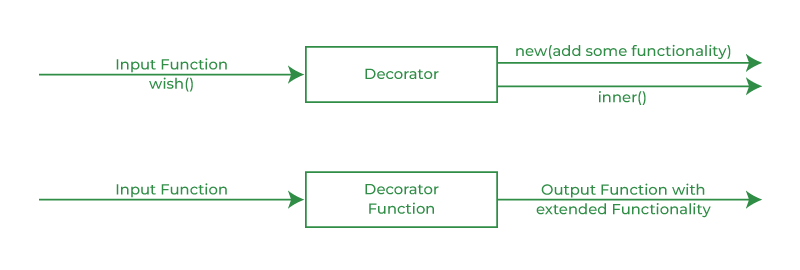</center>

- Chaining decorators means applying more than one decorator inside a function.
- Python allows us to implement more than one decorator to a function. It makes decorators useful for reusable building blocks as it accumulates several effects together.
- It is also known as nested decorators in Python.



In [ ]:
# code for testing decorator chaining
def decor1(func):
    def inner():
        x = func()
        return x * x
    return inner


def decor(func):
    def inner():
        x = func()
        return 2 * x
    return inner


@decor1
@decor
def num():
    return 10


print(num())

In [38]:
def decor1(func):
        def wrap():
               print("************")
               func()
               print("************")
        return wrap


def decor2(func):
        def wrap():
               print("@@@@@@@@@@@@")
               func()
               print("@@@@@@@@@@@@")
        return wrap


@decor1
@decor2
def sayhellogfg():
         print("Hello")


def saygfg():
         print("GeekforGeeks")


sayhellogfg()
saygfg()

************
@@@@@@@@@@@@
Hello
@@@@@@@@@@@@
************
GeekforGeeks


`Real-World Uses of Decorators`

    - Logging: Track function calls (e.g., @logger).
    - Authentication: Restrict access in web apps (e.g., Flask/Django).
    - Rate Limiting: Control API usage per user.
    - Caching: Store results using functools.lru_cache.
    - Retry Logic: Automatically retry failed network calls.